In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

In [2]:
pd.options.display.max_seq_items = 2000

In [3]:
data = pd.read_pickle('reconciled_data.pkl')

In [4]:
Ns_parafins = {
    'F_CH4_s_mol_s': 1, 'F_C2H6_s_mol_s': 2, 'F_C3H8_s_mol_s': 3,
       'F_C9': 9, 'F_C10': 10, 'F_C11': 11, 'F_C12': 12, 'F_C13': 13, 'F_C14': 14, 'F_C15': 15, 'F_C16': 16,
       'F_C17': 17, 'F_C18': 18, 'F_C19': 19, 'F_C20': 20, 'F_C21': 21, 'F_C22': 22, 'F_C23': 23, 'F_C24': 24,
       'F_C25': 25, 
       'F_C26': 26, 'F_C27': 27, 'F_C28': 28, 'F_C29': 29, 'F_C30': 30,
       'F_C31': 31, 'F_C32': 32,
       'F_C33': 33, 'F_C34': 34,
       # 'F_C35': 35, 
       # 'F_C36': 36,
}
Ns_olefins = {
    'F_C2H4_s_mol_s': 2,
       'F_Olef_C9': 9, 'F_Olef_C10': 10,
       'F_Olef_C11': 11, 'F_Olef_C12': 12, 'F_Olef_C13': 13, 'F_Olef_C14': 14, 'F_Olef_C15': 15,
       'F_Olef_C16': 16, 'F_Olef_C17': 17, 
       # 'F_Olef_C18': 18, 
}

In [5]:
Fn_exp_parafins = data[list(Ns_parafins.keys())]

Fn_exp_olefins = data[list(Ns_olefins.keys())]

Fn_exp_parafins.columns = Ns_parafins.values()
Fn_exp_parafins.columns = Fn_exp_parafins.columns.astype('int32')

Fn_exp_olefins.columns = Ns_olefins.values()
Fn_exp_olefins.columns = Fn_exp_olefins.columns.astype('int32')

In [6]:
Fn_exp = Fn_exp_parafins.copy()

In [7]:
for i in Ns_olefins.values():
    Fn_exp[i] = Fn_exp[i] + Fn_exp_olefins[i]

In [8]:
# drop rows with zeros
Fn_exp = Fn_exp[(Fn_exp != 0).all(axis=1)]
Fn_exp = Fn_exp.astype('float')

In [9]:
upsilon = Fn_exp_parafins / Fn_exp
upsilon = upsilon[(upsilon.notna()).all(axis=1)]

In [10]:
upsilon['T_R_K'] = data.T_R_K
upsilon['H2_CO'] = data.H2_CO
upsilon['P_abs_Pa'] = data.P_abs_Pa

In [11]:
upsilon = upsilon.melt(id_vars = ['T_R_K', 'H2_CO', 'P_abs_Pa'], var_name = 'n', value_name = 'upsilon_exp')

In [12]:
upsilon = upsilon.astype('float')

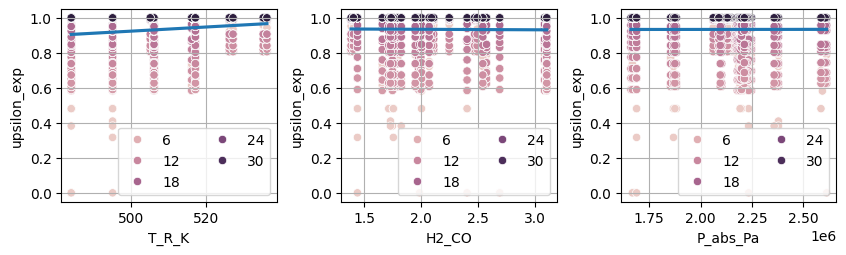

In [13]:
fig, ax = plt.subplots(1,3,figsize=(10,2.5))
plt.subplots_adjust(wspace=0.3)

sns.scatterplot(x='T_R_K', y='upsilon_exp', data=upsilon, ax = ax[0], hue = 'n')
sns.regplot(x='T_R_K', y='upsilon_exp', data=upsilon, ax = ax[0], marker = "")
ax[0].legend(ncols = 2)
ax[0].grid('both')
ax[0].set_ylim(-0.05, 1.05)

sns.scatterplot(x='H2_CO', y='upsilon_exp', data=upsilon, ax = ax[1], hue = 'n')
sns.regplot(x='H2_CO', y='upsilon_exp', data=upsilon, ax = ax[1], marker = "")
ax[1].legend(ncols = 2)
ax[1].grid('both')
ax[1].set_ylim(-0.05, 1.05)

sns.scatterplot(x='P_abs_Pa', y='upsilon_exp', data=upsilon, ax = ax[2], hue = 'n')
sns.regplot(x='P_abs_Pa', y='upsilon_exp', data=upsilon, ax = ax[2], marker = "")
ax[2].legend(ncols = 2)
ax[2].grid('both')
ax[2].set_ylim(-0.05, 1.05)


plt.show()

In [37]:
def calc_upsilon(beta, n, T):
    exponent = beta[0] + beta[1] * n + beta[2] * T + beta[3] * ( n == 2 )
    return 1 / ( 1 + ( 1 - ( ( n == 1 ) | ( n == 3 ) ) ) * np.exp( - exponent ) )

In [38]:
def residuals(beta, n, T):
    return upsilon.upsilon_exp.values - calc_upsilon(beta, n, T)

In [39]:
def SSR(beta, n, T):
    return ( residuals(beta, n, T) ** 2 ).sum()

In [40]:
beta0 = np.array([1, 0.1, 1e-3, 0.1])

n = upsilon.n.values
T = upsilon.T_R_K.values

In [41]:
sol = minimize(SSR, beta0,
             method='Nelder-Mead',
             bounds=None, 
             args = (n, T),
             options = {'maxfev': 3000},
             )

In [42]:
sol

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 5.974886961521364
             x: [-1.474e+01  3.270e-01  2.414e-02  2.669e+00]
           nit: 228
          nfev: 387
 final_simplex: (array([[-1.474e+01,  3.270e-01,  2.414e-02,  2.669e+00],
                       [-1.474e+01,  3.270e-01,  2.414e-02,  2.669e+00],
                       ...,
                       [-1.474e+01,  3.270e-01,  2.414e-02,  2.669e+00],
                       [-1.474e+01,  3.270e-01,  2.414e-02,  2.669e+00]],
                      shape=(5, 4)), array([ 5.975e+00,  5.975e+00,  5.975e+00,  5.975e+00,
                        5.975e+00]))

In [43]:
upsilon['upsilon_model'] = calc_upsilon(sol.x, n, T)

(-0.05, 1.05)

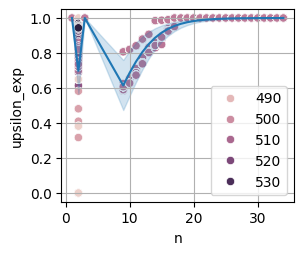

In [48]:
fig, ax = plt.subplots(figsize=(3,2.5))

sns.scatterplot(x='n', y='upsilon_exp', data=upsilon, ax = ax, hue = 'T_R_K')
sns.lineplot(x='n', y='upsilon_model', data=upsilon, ax = ax, errorbar=('pi', 95))
plt.grid('both')
plt.ylim(-0.05, 1.05)

In [49]:
sol.x

array([-14.73617704,   0.32696485,   0.02414478,   2.66918392])

In [50]:
np.save('params_upsilon.npy', sol.x)